<a href="https://colab.research.google.com/github/hdpark1208/StudyCode/blob/main/Algorithm/BJ/%EC%97%B0%EA%B5%AC%EC%86%8C2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 연구소 2

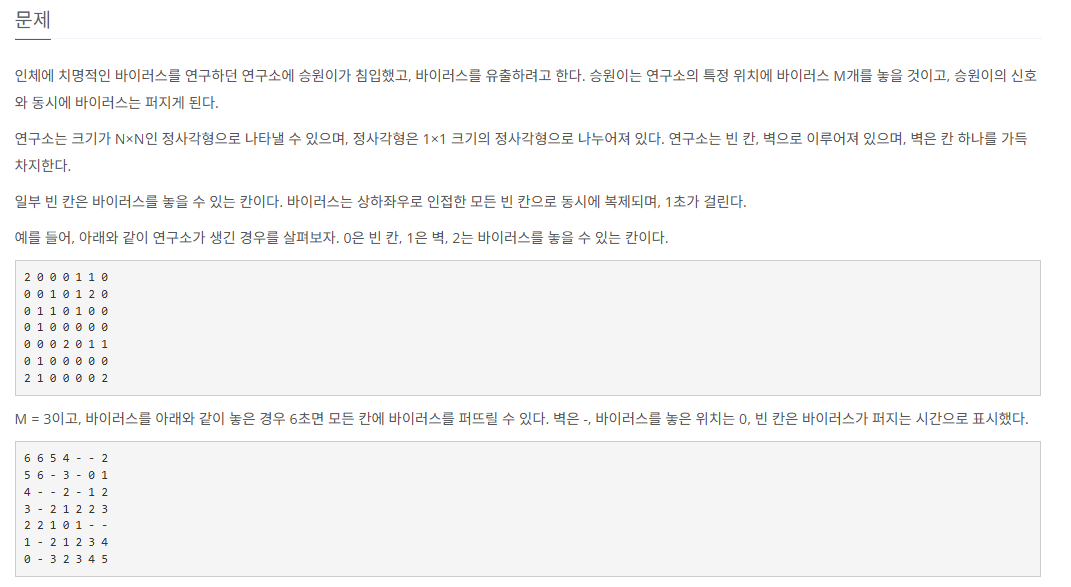

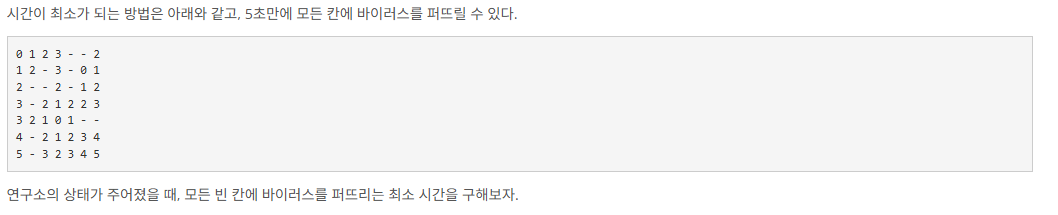

## 입력 출력 및 예제


* 입력

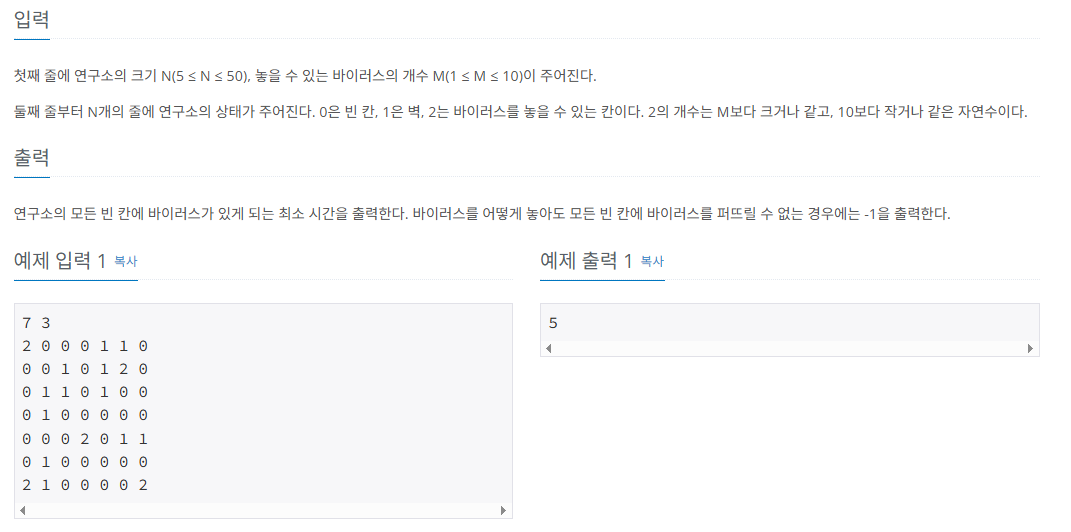

* 출력

* 예제

## 구상

* 바이러스 놓을 수 있는 칸이지만, 바이러스를 놓지 않았을 때는 빈칸 처리

## 코드

In [ ]:
from collections import deque
from itertools import combinations

N, M = map(int, input().split())
lab = [list(map(int, input().split())) for _ in range(N)]

virus_room = []

for i in range(N):
    for j in range(M):
        if lab[i][j] == 2:
            virus_room.append((i, j))


def spread(board, virus, time):
    q = deque(virus)
    new_virus = []

    dirs = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    while q:
        x, y = q.popleft()

        for dx, dy in dirs:
            nx = x + dx
            ny = y + dy

            if 0 <= nx < N and 0 <= ny < M and board[nx][ny] == 0:
                board[nx][ny] = 2
                new_virus.append((nx, ny))

    virus = new_virus
    time += 1

    return virus, time


answer = []

for virus in combinations(virus_room, M):
    infection = True

    empty = list(set(virus_room) - set(virus))
    board = [row[:] for row in lab]
    for x,y in empty:
        board[x][y] = 0

    time = 0

    while virus:
        board, virus, time = spread(board, virus, time)

    for i in range(N):
        for j in range(N):
            if board[i][j] == 0:
                infection = False
                break

    if infection:
        answer.append(time)

if answer:
    print(min(answer))
else:
    print(-1)

### 메모



* 깔끔하게 성공